### Importação das bibliotecas

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

### Análise de Dados

In [2]:
df_order_reviews = pd.read_csv(f"{os.getcwd()}\\documentos\\olist_order_reviews_dataset.csv")
df_order_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 17.8 MB


Limpeza dos espaços vazios das strings

In [3]:
df_order_reviews['review_comment_title'] = df_order_reviews['review_comment_title'].str.strip()
df_order_reviews['review_comment_message'] = df_order_reviews['review_comment_message'].str.strip()

O dataset apresenta dados nulos no título e nos comentários, porém nas notas da review se mantém ativas

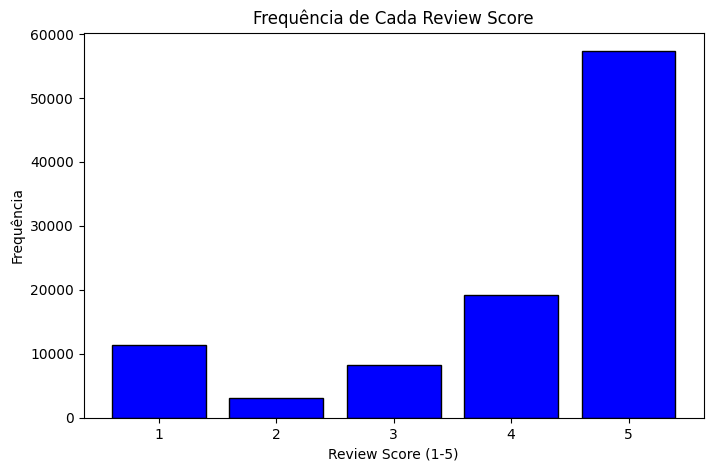

In [4]:
# Avaliação da Frequência de Cada Review
df_score_frequency = (
    df_order_reviews[['review_score']]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.bar(df_score_frequency.index.get_level_values('review_score'),
        df_score_frequency.values, color='blue', edgecolor='black')
plt.title("Frequência de Cada Review Score")
plt.xlabel("Review Score (1-5)")
plt.ylabel("Frequência")
plt.show()

Nessa versão abaixo, o order_reviews apresenta titulos similares, porém com letras maiúsculas, portanto para simplificar as frequências, será colocado o texto em caixa minúscula

In [5]:
# Avaliação da Frequência dos títulos Nulos
df_order_reviews[['review_comment_title']].value_counts()

review_comment_title     
Recomendo                    485
Ótimo                        447
Excelente                    367
recomendo                    361
Bom                          349
                            ... 
Entrega super Rápida           1
Nota máxima!                   1
Não foi entregue o pedido      1
OTIMA EMBALAGEM                1
Foto enganosa                  1
Name: count, Length: 4179, dtype: int64

In [6]:
df_order_reviews['review_comment_title'] = df_order_reviews['review_comment_title'].str.lower()

In [7]:
df_reviews_title_frequency = (
    df_order_reviews[['review_comment_title']].value_counts()
).reset_index(name="frequency")

df_reviews_title_frequency[df_reviews_title_frequency['frequency'] > 1]

,review_comment_title,frequency
0,recomendo,910
1,super recomendo,605
2,ótimo,497
3,bom,470
4,excelente,430
...,...,...
671,recebi pedido incompleto,2
672,muito bonita,2
673,bom custo beneficio,2
674,péssima meu produtdefeito,2


Pelo texto do título apresentar valores semelhantes, será aplicado a mesma lógica para o review_comment_message

In [8]:
df_order_reviews['review_comment_message'] = df_order_reviews['review_comment_message'].str.lower()

In [9]:
# Avaliação da Frequência dos comentários 
df_reviews_title_frequency = (
    df_order_reviews[['review_comment_message']].value_counts()
).reset_index(name="frequency")

df_reviews_title_frequency[df_reviews_title_frequency['frequency'] > 1]

,review_comment_message,frequency
0,muito bom,472
1,bom,342
2,recomendo,234
3,otimo,227
4,ótimo,197
...,...,...
1165,estou aguardando a encomenda. \r\nrecebi o avi...,2
1166,super recomendo!!!!!,2
1167,estou aguardando a entrega do produto.,2
1168,entregue bem antes do prazo.,2


#### Avaliação das Reviews Nulas

In [10]:
df_filtrado = df_order_reviews[df_order_reviews['review_comment_message'].isna()][
    ['order_id', 'review_score', 'review_comment_title', 'review_comment_message']
]

df_filtrado.info()

<class 'pandas.DataFrame'>
Index: 58247 entries, 0 to 99222
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   order_id                58247 non-null  str  
 1   review_score            58247 non-null  int64
 2   review_comment_title    1729 non-null   str  
 3   review_comment_message  0 non-null      str  
dtypes: int64(1), str(3)
memory usage: 4.0 MB


In [11]:
# Como o título nulo e as mensagens nulas nos casos filtrados poderia avaliar por meio da nota que não estão nulos

df_filtrado[df_filtrado['review_comment_title'].isna()]

,order_id,review_score,review_comment_title,review_comment_message
0,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN
1,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN
2,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN
5,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN
6,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN
...,...,...,...,...
99217,48f7ee67313eda32bfcf5b9c1dd9522d,5,NaN,NaN
99218,d699c734a0b1c8111f2272a3f36d398c,5,NaN,NaN
99219,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN
99220,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN


In [12]:
df_avaliacao_textos = df_order_reviews[['review_id','review_comment_message', 'review_comment_title']]

df_avaliacao_textos['title_lenght'] = df_avaliacao_textos['review_comment_title'].str.len()
df_avaliacao_textos['message_lenght'] = df_avaliacao_textos['review_comment_message'].str.len()

In [13]:
df_avaliacao_textos['title_lenght'].value_counts().reset_index(name='title_lenght_frequency')

,title_lenght,title_lenght_frequency
0,9.0,2004
1,5.0,1119
2,15.0,873
3,3.0,704
4,10.0,576
5,13.0,489
6,17.0,484
7,25.0,429
8,16.0,401
9,14.0,399


In [14]:
df_avaliacao_textos[df_avaliacao_textos['title_lenght'] == 0.0]

,review_id,review_comment_message,review_comment_title,title_lenght,message_lenght
49962,af070b6f68aef93db14f3af532e6d590,produto de fácil instalação. chegou em 3 dias.,,0.0,46.0
93916,10915c6e8a820f34f735c6a739a1b0ec,NaN,,0.0,NaN


In [15]:
df_avaliacao_textos['message_lenght'].value_counts().reset_index(name='message_lenght_frequency')

,message_lenght,message_lenght_frequency
0,9.0,1012
1,200.0,597
2,5.0,560
3,3.0,515
4,26.0,505
...,...,...
204,202.0,12
205,208.0,1
206,205.0,1
207,206.0,1


### Distribuição de Sentimento

In [16]:
df_order_reviews['feeling_state'] = df_order_reviews['review_score'].map(
    lambda x: 'negativo' if (x <= 2) else 'positivo' if (x > 3) else 'neutro'
)

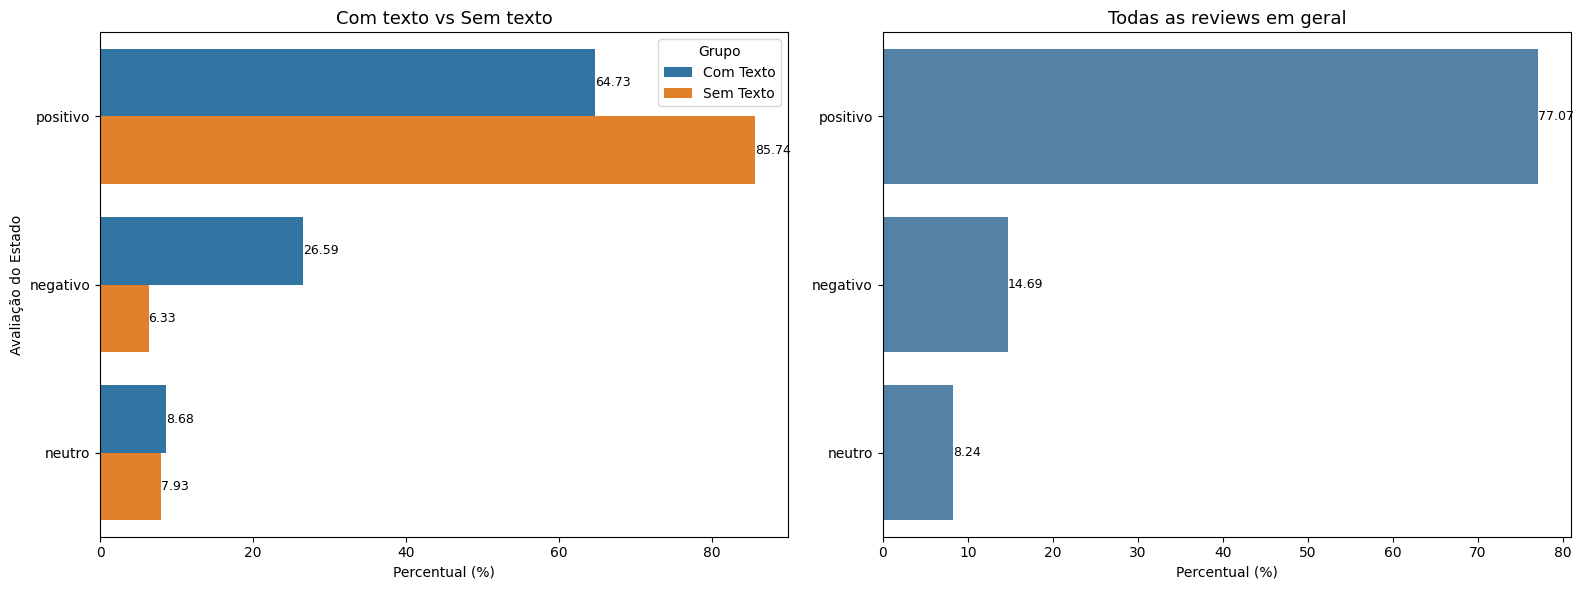

In [ ]:
with_text_message = (
                    df_order_reviews['review_comment_message']\
                    .fillna('')\
                    .astype("str")\
                    .str.strip().ne('')
                )

# Filtro dos casos cujo o texto da mensagem esteja nulo ou preenchido
df_with_text = df_order_reviews.loc[with_text_message].copy()
df_without_text = df_order_reviews.loc[~with_text_message].copy()

# Função para calcular a frequência e percentual do feeling state
def create_frequency(df, rotulo):
    freq = (
        df['feeling_state']
        .value_counts().reset_index(name='frequency')
    )

    # Calculo percentual
    freq['percent'] = round(freq['frequency'] / freq['frequency'].sum() * 100, 2)
    freq['flag'] = rotulo
    return freq


freq_with_text = create_frequency(df_with_text, "Com Texto")
freq_without_text = create_frequency(df_without_text, "Sem Texto")
all_frequency = create_frequency(df_order_reviews.copy(), "Todos os Casos")


# Plot de 2 Subtabelas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_comp = pd.concat([freq_with_text, freq_without_text], ignore_index=True)

sns.barplot(data=df_comp, x='percent', y='feeling_state', hue='flag', ax=axes[0])

axes[0].set_title('Com texto vs Sem texto', fontsize=13)
axes[0].xlabel('Percentual (%)')
axes[0].set_ylabel('Avaliação do Estado')
axes[0].legend(title='Grupo')

for container in axes[0].containers:
    axes[0].bar_label(container, fmt= "%.2f", fontsize=9)


sns.barplot(
    data=all_frequency, 
    x='percent', y='feeling_state',
    ax=axes[1], color='steelblue'
)
axes[1].set_title('Todas as reviews em geral', fontsize=13)
axes[1].set_xlabel('Percentual (%)')
axes[1].set_ylabel('')

for container in axes[1].containers:
    axes[1].bar_label(container, fmt= "%.2f", fontsize=9)

plt.tight_layout()
plt.show()

Mediante a essas análises percebe-se que a quantidade positiva de reviews sem texto apresenta um percentual maior que as outras classificações, e quando se filtra reviews sem texto aparentemente possui um percentual menor  